In [1]:
import plotly.express as px
import plotly as pl
import plotly.io as pio
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import seaborn as sb
import dash
from dash import Dash, html, dcc, Output, Input, callback

In [2]:
npa = pd.read_csv('Nutrition__Physical_Activity__and_Obesity.csv')
npa.head()

C:\Users\djanke2\AppData\Local\Temp\ipykernel_12832\191502378.py:1: DtypeWarning: Columns (0: Data_Value_Unit, 1: Total) have mixed types. Specify dtype option on import or set low_memory=False.
  npa = pd.read_csv('Nutrition__Physical_Activity__and_Obesity.csv')


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2016,2016,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2016,2016,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2016,2016,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2016,2016,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2016,2016,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


In [3]:
row_count = len(npa)

print(row_count)

69300


In [4]:
#Filter out 5 Specific States
states = ["Mississippi", "West Virginia", "Colorado", "Ohio", "California"]

filtered_npa = npa[npa["LocationDesc"].str.contains("|".join(states), case=False, na=False)]
filtered_npa.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
112,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(37.638640123, -120.999999538)",OWS,OWS1,Q036,VALUE,6,Income,"$15,000 - $24,999",INC,INC1525
113,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(37.638640123, -120.999999538)",OWS,OWS1,Q036,VALUE,6,Income,"$25,000 - $34,999",INC,INC2535
114,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(37.638640123, -120.999999538)",OWS,OWS1,Q036,VALUE,6,Income,"$35,000 - $49,999",INC,INC3550
115,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(37.638640123, -120.999999538)",OWS,OWS1,Q036,VALUE,6,Income,"$50,000 - $74,999",INC,INC5075
116,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(37.638640123, -120.999999538)",OWS,OWS1,Q036,VALUE,6,Income,"$75,000 or greater",INC,INC75PLUS


In [5]:
#See how many rows are now in filtered data
row_count = len(filtered_npa)

print(row_count)

6300


In [6]:
#Make Overall Year, Income, & State columns
filtered_npa["Year"] = filtered_npa["YearStart"]
filtered_npa["State"] = filtered_npa["LocationDesc"]
filtered_npa.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1,Year,State
112,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,OWS1,Q036,VALUE,6,Income,"$15,000 - $24,999",INC,INC1525,2016,California
113,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,OWS1,Q036,VALUE,6,Income,"$25,000 - $34,999",INC,INC2535,2016,California
114,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,OWS1,Q036,VALUE,6,Income,"$35,000 - $49,999",INC,INC3550,2016,California
115,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,OWS1,Q036,VALUE,6,Income,"$50,000 - $74,999",INC,INC5075,2016,California
116,2016,2016,CA,California,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,OWS1,Q036,VALUE,6,Income,"$75,000 or greater",INC,INC75PLUS,2016,California


In [7]:
#Look for obesity info
filtered_npa = filtered_npa[filtered_npa["Topic"].str.contains("Obesity", case=False, na=False)]

#Get the correct value types
filtered_npa["Data_Value"] = pd.to_numeric(filtered_npa["Data_Value"], errors="coerce")

#Plot information for specific info
plot_filtered_npa = filtered_npa.dropna(subset=["Age_yrs", "Data_Value", "LocationDesc"])

In [8]:
plot_filtered_npa = (
    plot_filtered_npa
    .groupby(["State", "Age_yrs"])["Data_Value"]
    .mean()
    .reset_index()
)

In [9]:
states = plot_filtered_npa["State"].unique()

fig1 = go.Figure()

# Add one trace per state
for state in states:
    state_npa = plot_filtered_npa[plot_filtered_npa["State"] == state]
    
    fig1.add_trace(
        go.Scatter(
            x=state_npa["Age_yrs"],
            y=state_npa["Data_Value"],
            mode="lines+markers",
            name=state,
            visible=(state == states[0])  
        )
    )

# Create dropdown buttons
buttons = []

for i, state in enumerate(states):
    visibility = [False] * len(states)
    visibility[i] = True
    
    buttons.append(
        dict(
            label=state,
            method="update",
            args=[
                {"visible": visibility},
                {"title": "Obesity Rates by Age in {state}"}
            ]
        )
    )
# Add dropdown to layout
fig1.update_layout(
    title="Obesity Rates by Age in {states[0]}",
    xaxis_title="Age Group",
    yaxis_title="Obesity Rate (%)",
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            x=1.15,
            y=1
        )
    ]
)

fig1 = px.line(
    plot_filtered_npa,
    x="Age_yrs",
    y="Data_Value",
    color="State",
    markers="true",
    labels={'Data_Value': 'Obesity Percentage (%)', 'Age_yrs': 'Age Groups'},
    title="State Obesity Rates by Age",
 )

fig1.show()

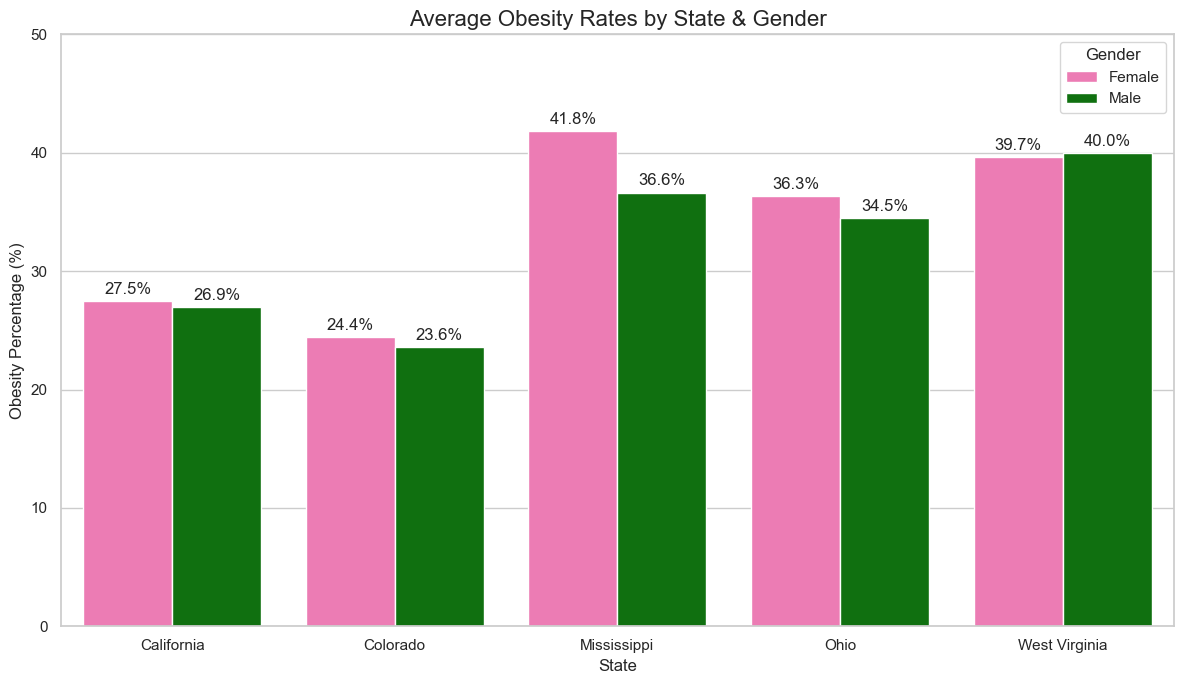

In [10]:


#Filter 5 Specific States
target_states = ['Mississippi', 'Ohio', 'Colorado', 'West Virginia', 'California']
obesity_question = 'Percent of adults aged 18 years and older who have obesity'

#Filter for the 'Sex' category to get the Male/Female Data
filtered_npa = npa[
    (npa['LocationDesc'].isin(target_states)) & 
    (npa['Question'] == obesity_question) & 
    (npa['StratificationCategory1'] == 'Sex')
].copy()

#Convert Data_Value to number for plotting
filtered_npa['Data_Value'] = pd.to_numeric(filtered_npa['Data_Value'], errors='coerce')
filtered_npa = filtered_npa.dropna(subset=['Data_Value'])

#Get Average percentage per state/sex across 2016-2024
summary = filtered_npa.groupby(['LocationDesc', 'Stratification1'])['Data_Value'].mean().reset_index()
#Use Seaborn for Chart
custom_palette = {"Female": "hotpink", "Male": "green"}
plt.figure(figsize=(12, 7))
sb.set_theme(style="whitegrid") 

ax = sb.barplot(
    data=summary, 
    x='LocationDesc', 
    y='Data_Value', 
    hue='Stratification1', 
    palette=custom_palette
)

#Add labels and font sizes - The "red" percentage info was given to me by ai.
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# 7. Final Formatting
plt.title('Average Obesity Rates by State & Gender', fontsize=16)
plt.ylabel('Obesity Percentage (%)', fontsize=12)
plt.xlabel('State', fontsize=12)
plt.ylim(0, 50) 
plt.legend(title='Gender')
plt.tight_layout()

plt.show()

Obesity Prevalence (%) by State and Sex:
Stratification1     Female       Male
LocationDesc                         
California       27.455556  26.944444
Colorado         24.411111  23.588889
Mississippi      41.833333  36.644444
Ohio             36.344444  34.511111
West Virginia    39.655556  39.977778

In [11]:


#Change above chart to Plotly Express for DASH

#Colors for Bars
custom_palette = {"Female": "hotpink", "Male": "green"}

#Bar Chart
fig2 = px.bar(
    summary, 
    x='LocationDesc', 
    y='Data_Value', 
    color='Stratification1',         
    barmode='group',                 
    color_discrete_map=custom_palette, 
    text_auto='.1f',                
    title='Average State Obesity Rates by Gender',
    labels={                      
        'LocationDesc': 'State', 
        'Data_Value': 'Obesity Percentage (%)', 
        'Stratification1': 'Gender'
    })
#Layout Specs
fig2.update_layout(
    yaxis_range=[0, 50],
    title_x=0.5,                 
    uniformtext_mode='hide',  
    uniformtext_minsize=8)

#Make Sure % sign shows on the chart with the data numbers
fig2.update_traces(texttemplate='%{y:.1f}%', textposition='outside')

#Dash Information
#dcc.Graph(id='obesity-bar-chart', figure=fig2)

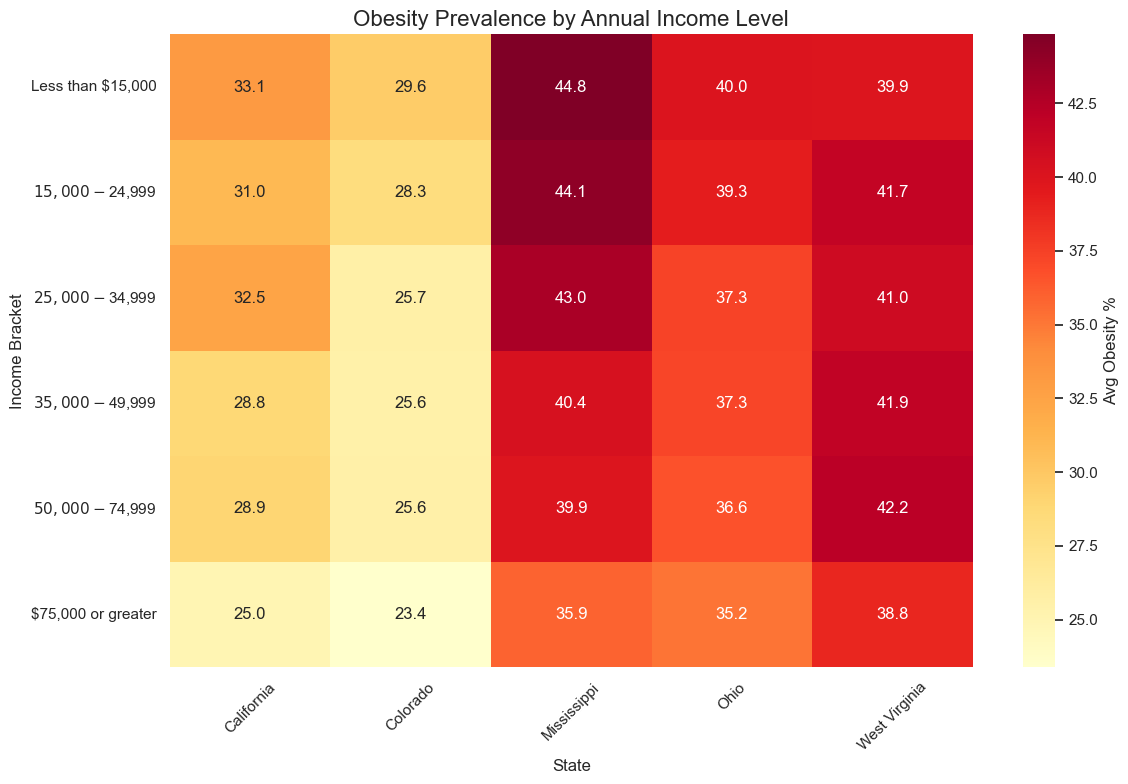

In [12]:
target_states = ['Mississippi', 'Ohio', 'Colorado', 'West Virginia', 'California']
obesity_question = 'Percent of adults aged 18 years and older who have obesity'

#Filter for Income levels
income_npa = npa[
    (npa['LocationDesc'].isin(target_states)) & 
    (npa['Question'] == obesity_question) & 
    (npa['StratificationCategory1'] == 'Income')
].copy()

#Clean up Data
income_npa['Data_Value'] = pd.to_numeric(income_npa['Data_Value'], errors='coerce')
income_npa = income_npa.dropna(subset=['Data_Value'])

#Combine/Group
income_summary = income_npa.groupby(['LocationDesc', 'Stratification1'])['Data_Value'].mean().reset_index()
pivot_income = income_summary.pivot(index='Stratification1', columns='LocationDesc', values='Data_Value')

#Put Incomes in order
income_order = [
    'Less than $15,000', '$15,000 - $24,999', '$25,000 - $34,999', 
    '$35,000 - $49,999', '$50,000 - $74,999', '$75,000 or greater'
]
pivot_income = pivot_income.reindex([i for i in income_order if i in pivot_income.index])

#Heatmap
plt.figure(figsize=(12, 8))
sb.heatmap(pivot_income, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Avg Obesity %'})
plt.title('Obesity Prevalence by Annual Income Level', fontsize=16)
plt.ylabel('Income Bracket')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
##Change above chart to Plotly Express for DASH
#The following information is defined above:
income_summary = income_npa.groupby(['LocationDesc', 'Stratification1'])['Data_Value'].mean().reset_index()
pivot_income = income_summary.pivot(index='Stratification1', columns='LocationDesc', values='Data_Value')
pivot_income = pivot_income.reindex([i for i in income_order if i in pivot_income.index])

#Heatmap
fig3 = px.imshow(
    pivot_income,
    labels=dict(x="State", y="Income Bracket", color="Avg Obesity %"),
    x=pivot_income.columns,
    y=pivot_income.index,
    text_auto=".1f",             
    aspect="auto",        
    color_continuous_scale="YlOrRd", 
    title='Obesity Prevalence by Annual Income Level')

#Layout Information
fig3.update_xaxes(side="bottom", tickangle=45)
fig3.update_layout(
    title_x=0.5,
    yaxis_title="Income Bracket",
    xaxis_title="State")



In [66]:

##Used AI to Help Get This Dashboard Going and Made My Own Adjustments
app = Dash()
app.layout = html.Div([
      html.Div([
                #Line Chart on the left side of the screen with Page Title
        html.Div([
            html.H1("Obesity in the United States", style={'textAlign': 'center', 'color': 'lightyellow'}),
            html.H2("California, Colorado, Mississippi, Ohio, and West Virginia", style={'textAlign': 'center', 'color': 'white'}),
         
           # This pushes the line Chart down
            html.Div(style={'flex-grow': '1'}), 
            dcc.Graph(id='line', figure=fig1)
            ], style={'width': '45%', 'display': 'flex', 'flexDirection': 'column', 'height': '102vh'}),

            #Photo to be centered in left column
            html.Img(
                src="https://raw.githubusercontent.com/djanke2/Interactive-Data_Spring26/refs/heads/main/HealthyImage.png", 
                style={'width': '28%', 'height': '28%','display': 'flex', 'flexDirection': 'column', 'margin': '200px 0', 'borderRadius': '20px'}),



        #Bar Chart and Heatmap on the right side of the screen
        html.Div([
            
            #Bar Chart on top of right column
            html.Div([
                dcc.Graph(id='bar', figure=fig2)
            ], style={'height': '50%', 'padding': '20px'}),
            
            #Heatmap on bottom of right column
            html.Div([
                dcc.Graph(id='heatmap', figure=fig3)
            ], style={'height': '50%','padding': '20px'})

            #AI made the style guidelines and I'm trying to figure out what flex and flexDirection are.

        ], style={'width': '55%', 'display': 'flex', 'flexDirection': 'column', 'padding': '10px'})

    ], style={'display': 'flex', 'flexDirection': 'row', 'backgroundColor': '#1a1a1a', 'padding': '20px'})
])

if __name__ == '__main__':
    app.run_server(debug=True)